In [5]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/sample_superstore.csv",
    encoding="latin1"
)

In [6]:
df.columns
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [9]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [10]:

df.duplicated().sum()

np.int64(0)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
total_sales = df["Sales"].sum()
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
print('$'+ str(total_sales))

$2297200.8603


In [13]:
average_order_value = df["Sales"].mean()
print ( df["Sales"].mean())
print(f"Average Order Value: ${average_order_value:.2f}")

229.85800083049827
Average Order Value: $229.86


In [14]:
df["Sales"].median()

np.float64(54.489999999999995)

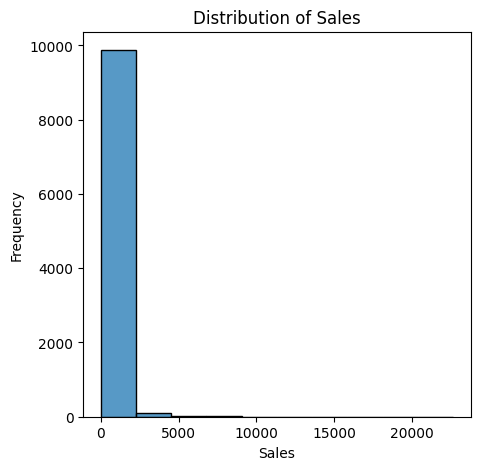

In [15]:
plt.figure(figsize=(5,5))

sns.histplot(df["Sales"], bins=10)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [16]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

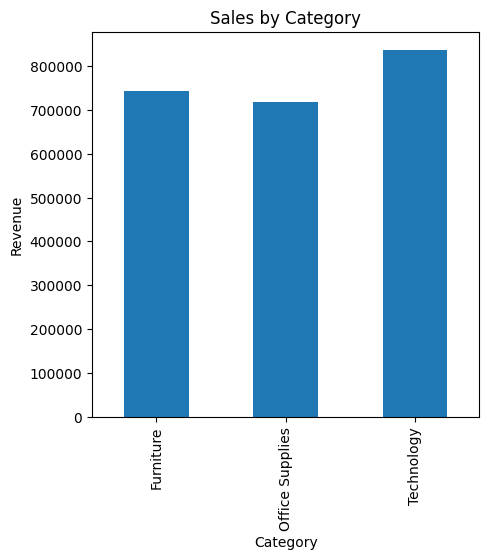

In [17]:
category_sales.plot(kind="bar", figsize=(5,5))

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [18]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

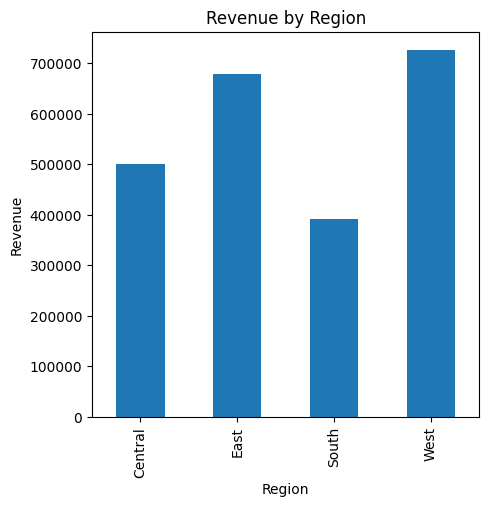

In [19]:
region_sales.plot(kind="bar", figsize=(5,5))

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.show()

In [20]:
df["Order Date"]

0      2016-11-08
1      2016-11-08
2      2016-06-12
3      2015-10-11
4      2015-10-11
          ...    
9989   2014-01-21
9990   2017-02-26
9991   2017-02-26
9992   2017-02-26
9993   2017-05-04
Name: Order Date, Length: 9994, dtype: datetime64[us]

In [21]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

In [22]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

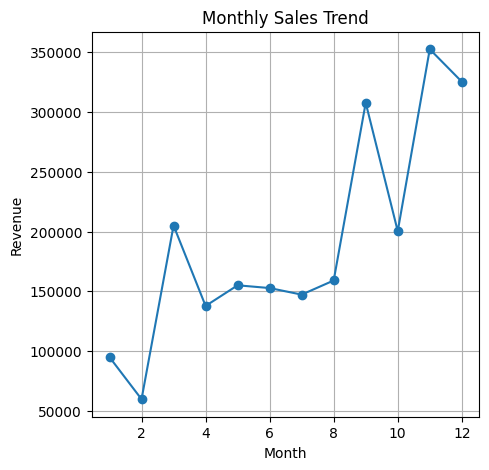

In [23]:
plt.figure(figsize=(5,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [27]:
df["Customer ID"].nunique()

793

In [31]:
customer_orders= df.groupby("Customer ID")["Order ID"].count()  
print(customer_orders)

Customer ID
AA-10315    11
AA-10375    15
AA-10480    12
AA-10645    18
AB-10015     6
            ..
XP-21865    28
YC-21895     8
YS-21880    12
ZC-21910    31
ZD-21925     9
Name: Order ID, Length: 793, dtype: int64


In [33]:
repeat_customers = customer_orders[customer_orders > 1]
repeat_customers.count()    

np.int64(788)

In [34]:
one_time_customers=customer_orders[customer_orders == 1]
one_time_customers.count()  

np.int64(5)

In [35]:
repeat_rate = (repeat_customers.count() / df["Customer ID"].nunique()) * 100
print (f"Repeat Customer Rate: {repeat_rate:.2f}%") 

Repeat Customer Rate: 99.37%


In [42]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)
top_customers.head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

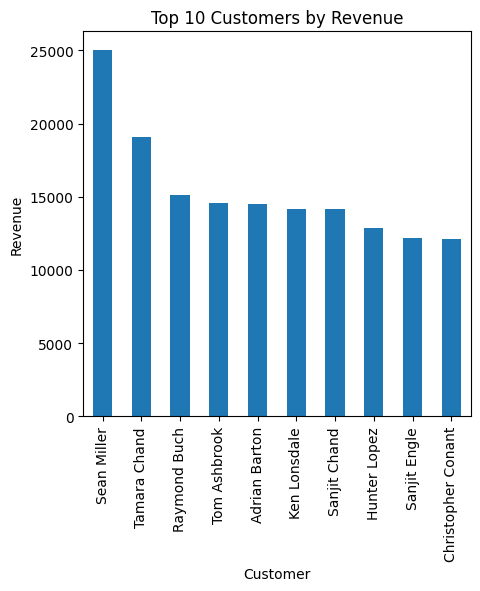

In [44]:
top_customers.head(10).plot(
    kind="bar",
    figsize=(5,5)
)
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")

plt.show()

In [47]:
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
)

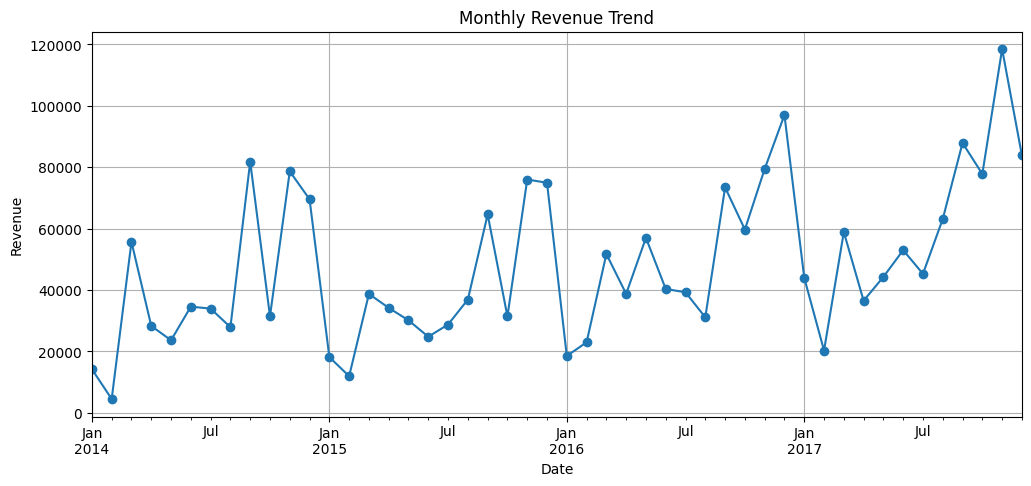

In [48]:
plt.figure(figsize=(12,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [59]:
rolling_avg=monthly_sales.rolling(window=3).mean()

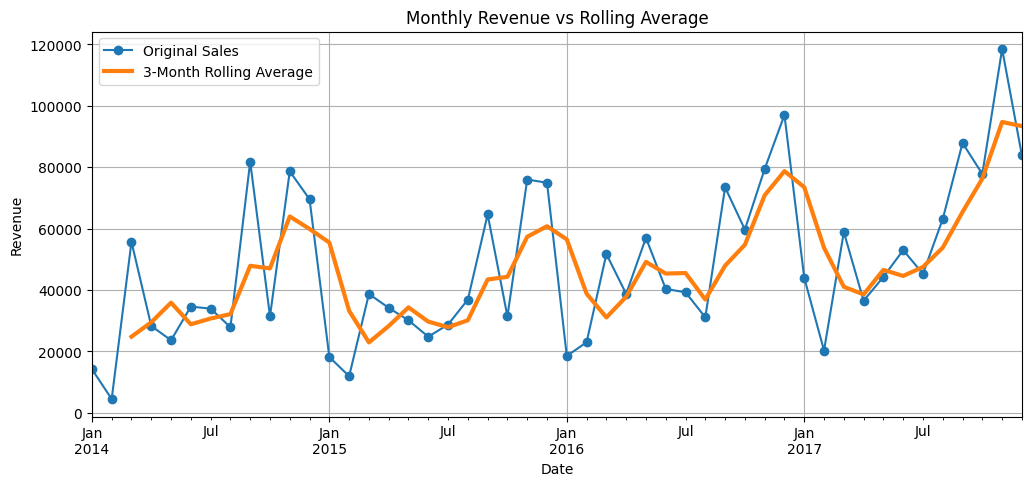

In [60]:
plt.figure(figsize=(12,5))

monthly_sales.plot(
    label="Original Sales",
    marker="o"
)

rolling_avg.plot(
    label="3-Month Rolling Average",
    linewidth=3
)

plt.title("Monthly Revenue vs Rolling Average")

plt.xlabel("Date")
plt.ylabel("Revenue")

plt.legend()

plt.grid(True)

plt.show()

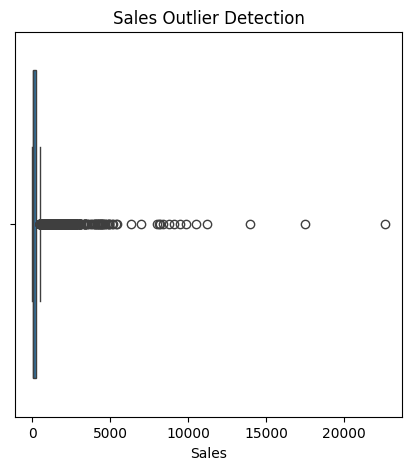

Q1: 17.28, Q3: 209.94, IQR: 192.66


In [65]:
plt.figure(figsize=(5,5))

sns.boxplot(x=df["Sales"])

plt.title("Sales Outlier Detection")

plt.show()

Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")

In [67]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Lower Bound: -271.71000000000004, Upper Bound: 498.93


In [71]:
outliers = df[(df["Sales"] < lower_bound) | (df["Sales"] > upper_bound)]
outliers.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152,2014,6
10,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092,2014,6
11,12,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.4240,4,0.20,68.3568,2014,6


In [72]:
numeric_df = df.select_dtypes(include=["number"])

correlation_matrix = numeric_df.corr()

correlation_matrix

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Year,Month
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497,0.015430,-0.018732
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961,0.004299,0.026234
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064,-0.009679,-0.000625
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253,-0.005810,0.023355
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487,-0.002662,-0.004935
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000,0.004670,-0.000502
Year,0.015430,0.004299,-0.009679,-0.005810,-0.002662,0.004670,1.000000,-0.020183
Month,-0.018732,0.026234,-0.000625,0.023355,-0.004935,-0.000502,-0.020183,1.000000


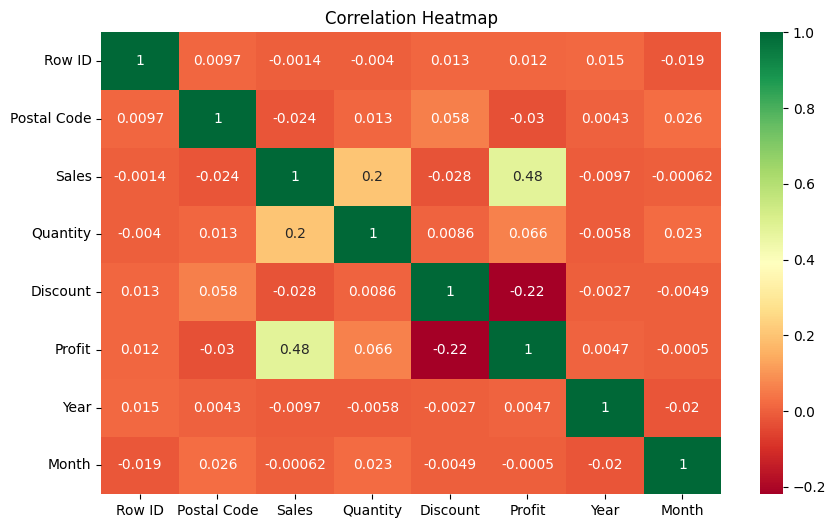

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdYlGn",
)

plt.title("Correlation Heatmap")

plt.show()

In [86]:
forecast_df= monthly_sales.reset_index()
forecast_df.columns = ["Order Date", "Sales"]
forecast_df.head()

,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


In [87]:
forecast_df.to_csv(
    "../data/processed/monthly_sales_forecast.csv",
    index=False
)